In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Train over Original Dataset

In [2]:
df_class = pd.read_csv(r"df_main_classi_noise_original_headers.csv")

In [3]:
# split train and test data
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_class, test_size=0.2, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler, scale
import statsmodels.api as sm

# train data
X_train = train.drop(columns=['healthcare_access'])
# X_names = X
y_train = train['healthcare_access']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = sm.add_constant(X_train)

# test data
X_test = test.drop(columns=['healthcare_access'])
# X_names = X
y_test = test['healthcare_access']

X_test = scaler.transform(X_test)
X_test = sm.add_constant(X_test)


### Logistic Regression Models

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
np.random.seed(42)

strengths = [1e0 ,1e1, 1e2, 1e3, 1e4, 1e5]

#l1 validation 

results1 = {}
print('l1')
for strength in strengths:
    print(strength)
    model = LogisticRegression(penalty = 'l1', C = strength, solver = 'liblinear', max_iter = 1000)
    model.fit(X_train,y_train) 
    avg_score = model.score(X_train,y_train)
    results1[strength] = avg_score


l1
1.0
10.0
100.0
1000.0
10000.0
100000.0


In [9]:
results2 = {}
print('l2')
for strength in strengths:
    print(strength)
    model = LogisticRegression(penalty = 'l2', C = strength, solver = 'lbfgs', max_iter = 100000)
    model.fit(X_train,y_train) 
    avg_score = model.score(X_test,y_test)
    results2[strength] = avg_score

l2
1.0
10.0
100.0
1000.0
10000.0


D:\Python3913\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


100000.0


D:\Python3913\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
best_strength_l1 = max(results1, key = results1.get) # gamma = 100
best_strength_l2 = max(results2, key = results2.get) # gamma = 1000

print(best_strength_l1, best_strength_l2) # 100000  1

100000.0 1.0


Text(0.5, 1.0, 'Logistic Regression Plot')

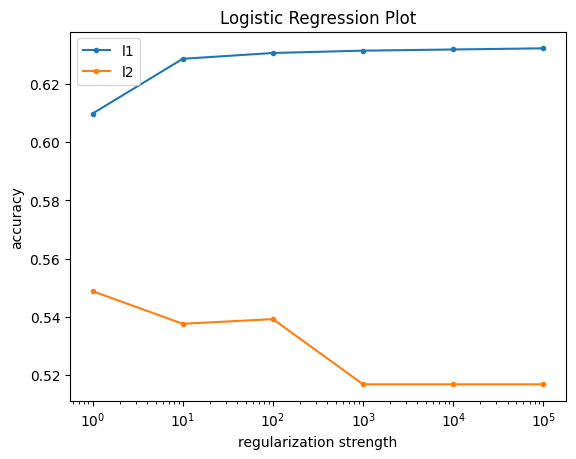

In [11]:
plt.plot(strengths, [results1[strength] for strength in strengths], '.-')
plt.plot(strengths, [results2[strength] for strength in strengths], '.-')
plt.xscale('log')
plt.legend(['l1', 'l2'])
plt.ylabel('accuracy')
plt.xlabel('regularization strength')
plt.title('Logistic Regression Plot')

# Train over 100K Dataset

In [12]:
df_100k = pd.read_csv("df_main_classi_noise_100k_headers.csv")


In [13]:
# split train and test data
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_100k, test_size=0.2, random_state=42)

In [14]:

# train data
X_train = train.drop(columns=['avg_death_rate', 'healthcare_access'])
# X_names = X
y_train = train['healthcare_access']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = sm.add_constant(X_train)

# test data
X_test = test.drop(columns=['avg_death_rate','healthcare_access'])
# X_names = X
y_test = test['healthcare_access']

X_test = scaler.transform(X_test)
X_test = sm.add_constant(X_test)


In [15]:
# best Logistic Regression L2 model 

l2_model = LogisticRegression(penalty = 'l2', C = 1, solver = 'lbfgs', max_iter = 10000000)
l2_model.fit(X_train,y_train)
avg_score = l2_model.score(X_test,y_test)

# ran 4 mins

In [ ]:
# best Logistic Regression L1 model 
l1_model = LogisticRegression(penalty = 'l1', C = 100000, solver = 'liblinear', max_iter = 1000000)
l1_model.fit(X_train,y_train) 
l1_avg_score = l1_model.score(X_test,y_test)
print(l1_avg_score)

# more than 16 hours

In [ ]:
print(avg_score)

In [ ]:
# important features

# # calculates the weights of each feature
# weights_l2 = l2_model.coef_[0]*(X_train.max(axis=0)-X_train.min(axis = 0))/X_train.std(axis=0)
# weights_l1 = l1_model.coef_[0]*(X_train.max(axis=0)-X_train.min(axis = 0))/X_train.std(axis=0)

from sklearn.inspection import permutation_importance

# compute importances
model_fi = permutation_importance(l1_model, X_train, y_train)
model_fi['importances_mean'] 

In [ ]:
flag = 0
for i in sorted_idxl1:
    if flag < 50:
        flag = flag+1
        print(f"{X_train.columns[i]}:{model_fi['importances_mean'][i]}")

In [ ]:
# # sort the weights in descending order
# sorted_idxl2 = [abs(ele) for ele in weights_l2].argsort()[::-1]
# sorted_idxl1 = [abs(ele) for ele in weights_l1].argsort()[::-1]

In [ ]:
# flag = 0
# for i in sorted_idxl2:
#     if flag < 20:
#         flag = flag+1
#         print(f"{X_train.columns[i]}:{weights_l2[i]}")